0. Installations

In [1]:
!pip install ultralytics roboflow sahi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: opencv-python
    Found existing installat

1. Data Loading


In [2]:
from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
rf = Roboflow(api_key=user_secrets.get_secret("ROBOFLOW_API_KEY"))
project = rf.workspace("project-6jait").project("final_try")
version = project.version(4)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Final_try-4 in yolov11:: 100%|██████████| 2010/2010 [00:00<00:00, 6889.65it/s]


2. Model Training (Optimization for Recall)


In [3]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=150,
    imgsz=1024,
    batch=-1,
    patience=20,
    mosaic=1.0,
    mixup=0.2
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Final_try-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  4,  5,  6,  7,  8, 10, 15, 17, 18, 19, 22, 23, 25, 32, 35, 36, 38, 40, 41, 42, 43, 47, 48, 53, 56, 58, 59, 60, 63, 65])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7beb668dddf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,

3. SAHI Inference for High Recall

In [4]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import os
import shutil
from google.colab import files

detection_model = AutoDetectionModel.from_pretrained(
    model_type="yolov11",
    model_path="runs/detect/train/weights/best.pt",
    confidence_threshold=0.15,
    device="cuda:0"
)

report_dir = "report_images"
os.makedirs(report_dir, exist_ok=True)

# Limited it to first 10 for quick report
test_images = sorted([f for f in os.listdir(f"{dataset.location}/test/images") if f.endswith('.jpg')])[:10]

for img_name in test_images:
    img_path = os.path.join(f"{dataset.location}/test/images", img_name)

    result = get_sliced_prediction(
        img_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    result.export_visuals(export_dir=report_dir, file_name=img_name.replace('.jpg', '_pred'))

Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.


4. Share of Shelf Analytics


image 1/35 /kaggle/working/Final_try-4/test/images/db1050_jpg.rf.6c337978ee69a3a3a31ce3063e861053.jpg: 1024x1024 1 q13, 68.7ms
image 2/35 /kaggle/working/Final_try-4/test/images/db1127_jpg.rf.61a0266165bd6c8bec8f851b88a941c7.jpg: 1024x1024 9 q121s, 59.9ms
image 3/35 /kaggle/working/Final_try-4/test/images/db1170_jpg.rf.c7c3dd2d1600ab4f4ae08b22acf44b7f.jpg: 1024x1024 4 q106s, 58.9ms
image 4/35 /kaggle/working/Final_try-4/test/images/db1205_jpg.rf.c02173b52c990ff307ad8896a541f7b6.jpg: 1024x1024 6 q109s, 56.1ms
image 5/35 /kaggle/working/Final_try-4/test/images/db1210_jpg.rf.78c93d96b882930f89575010a4b3be97.jpg: 1024x1024 2 q286s, 57.3ms
image 6/35 /kaggle/working/Final_try-4/test/images/db1212_jpg.rf.6c1c5f6b8918d257a07545f7ec4c0840.jpg: 1024x1024 2 q286s, 55.0ms
image 7/35 /kaggle/working/Final_try-4/test/images/db1268_jpg.rf.90d1222a97077ebbd703047fff8d42c7.jpg: 1024x1024 26 q214s, 55.0ms
image 8/35 /kaggle/working/Final_try-4/test/images/db1307_jpg.rf.5aef1e6ad32d866860e3e3b38f60d7e4

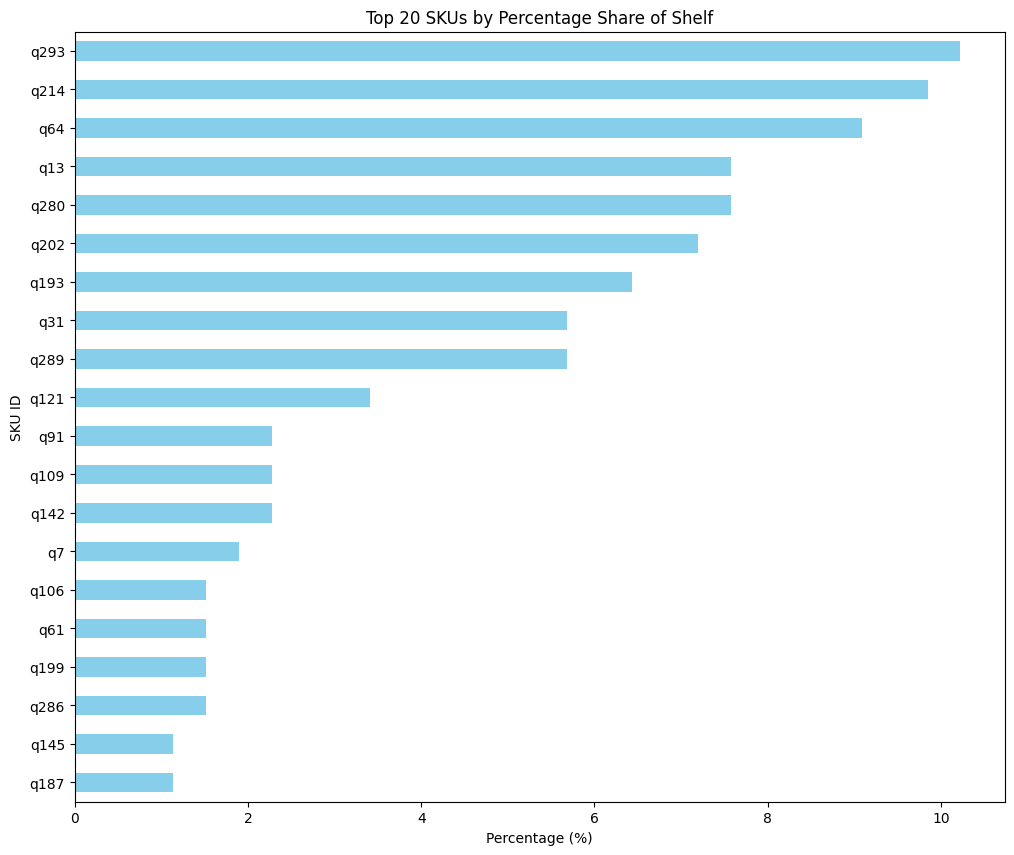

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

model = YOLO("runs/detect/train/weights/best.pt")

results = model.predict(source=f"{dataset.location}/test/images", conf=0.15)

all_labels = []
for r in results:
    for c in r.boxes.cls:
        all_labels.append(model.names[int(c)])

df = pd.DataFrame(all_labels, columns=['SKU'])
counts = df['SKU'].value_counts()
percentages = (counts / len(all_labels)) * 100

plt.figure(figsize=(12, 10))
percentages.head(20).plot(kind='barh', color='skyblue')
plt.title("Top 20 SKUs by Percentage Share of Shelf")
plt.xlabel("Percentage (%)")
plt.ylabel("SKU ID")
plt.gca().invert_yaxis()
plt.show()


5. Download Files & Folders

In [6]:
shutil.make_archive("shelf_report", 'zip', report_dir)

'/kaggle/working/shelf_report.zip'

In [7]:
import os
import shutil

# Zip the training results folder
shutil.make_archive("training_metrics", 'zip', "runs/detect/train/")

'/kaggle/working/training_metrics.zip'